# 08. Feature Extraction from Unstructured Data
## 📚 Learning Objectives

By completing this notebook, you will:
- Extract simple features from **text** (word count, character count, etc.)
- Extract simple features from **images** (pixel statistics, shape)
- Understand how unstructured data can be turned into tabular features for ML

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 2, lesson 04 "Feature Transformation" — encoding turns categories into numbers; this lesson does the same for text and images.

**Used later in:** Course 07 (AIAT 121) — Unit 1, which replaces these counts with proper text preprocessing, and Course 08 (AIAT 122) — Unit 2, which learns image features instead of hand-coding them.

---

## Introduction

Unstructured data (text, images) must be converted into **numeric features** before use in most ML models. This notebook shows simple, interpretable feature extraction for both.


## 🎯 The case: the year hand-made features lost

Until 2012, turning an image into numbers was a craft. Researchers designed features by
hand — **SIFT**, **SURF**, **HOG**, bags of visual words — and competed on how cleverly
those descriptors were built. Then at the **ImageNet Large Scale Visual Recognition
Challenge 2012**, Krizhevsky, Sutskever and Hinton entered **AlexNet**, a convolutional
network trained on two NVIDIA GTX 580 GPUs over about a week. It scored a top-5 error of
**15.3%** against roughly **26%** for the best hand-engineered runner-up. The gap was too
large to argue with, and the field changed within a year: features would be *learned from
the data*, not designed by a person.

**Why you are learning the hand-made version anyway.** Because you are about to watch it
fail, on real data, with a number attached. This notebook extracts mean pixel intensity
from 1,797 genuine 8×8 handwritten-digit scans and finds that the spread **between** digit
classes is **0.42** while the typical spread **within** a single class is **0.52**. Two
people writing the same '3' differ more than the average '3' differs from the average '8'.
The feature is not weak — it is worse than useless for this task, and you can see exactly
why: averaging every pixel throws away *where the ink is*, which is the only thing that
distinguishes a 3 from an 8.

That is the most valuable thing a feature-engineering lesson can give you: a concrete,
measured demonstration of the moment hand-made summaries stop being enough.


## The Story

**BEFORE**: You can work with structured data (tables) but don't know how to extract features from text/images.

**AFTER**: You'll learn feature extraction from unstructured data: text processing, image features, and preparing them for ML!

**Why this matters**: Feature Extraction from Unstructured Data is essential for building complete, professional data science solutions!

---

## Part 1: Text Feature Extraction

Extract basic features from raw text: word count, character count, average word
length, digit count, uppercase count.

The text is real: the free-text `desc` field that Montgomery County dispatchers typed
for each 911 call.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Text or image data
- Libraries for feature extraction

**Outputs:** What you'll see when you run the cells

- Extracted features
- Printed summaries

---

In [1]:
# WHAT: Define extract_text_features and run it on real 911 dispatcher descriptions.
# WHY: Models need numbers - counting words, characters, and digits turns raw text into a feature table.

import pandas as pd
import numpy as np

def extract_text_features(text: str) -> dict:
    """Extract simple numeric features from a text string."""
    if not isinstance(text, str) or not text.strip():
        return {"word_count": 0, "char_count": 0, "avg_word_len": 0.0,
                "digit_count": 0, "upper_count": 0}
    words = text.split()
    char_count = len(text)
    word_count = len(words)
    avg_word_len = sum(len(w) for w in words) / word_count if word_count else 0.0
    digit_count = sum(1 for c in text if c.isdigit())
    upper_count = sum(1 for c in text if c.isupper())
    return {
        "word_count": word_count,
        "char_count": char_count,
        "avg_word_len": round(avg_word_len, 2),
        "digit_count": digit_count,
        "upper_count": upper_count,
    }

# Real free-text: the 'desc' column of the Montgomery County 911 log.
DATA_DIR = '../../../Course 04/datasets/raw/'
calls = pd.read_csv(DATA_DIR + 'montgomery_911_calls.csv',
                    usecols=['desc', 'title'], nrows=20000)
calls['category'] = calls['title'].str.split(':').str[0]

# Show the extractor on three real descriptions first, so you can read them.
docs = calls['desc'].head(3).tolist()
rows = [extract_text_features(t) for t in docs]
df_text = pd.DataFrame(rows)
df_text.insert(0, "text", [d[:60] + '...' for d in docs])
print("Text feature extraction on three real dispatch descriptions:")
print(df_text.to_string())

# Now run it over 20,000 real descriptions and look at the resulting feature table.
feature_rows = [extract_text_features(t) for t in calls['desc']]
df_features = pd.DataFrame(feature_rows)
df_features['category'] = calls['category'].values

print(f"\nExtracted features for {len(df_features):,} real call descriptions:")
print(df_features.drop(columns='category').describe().round(2).to_string())

print("\nDo the features differ by emergency category? (mean per category)")
by_cat = df_features.groupby('category').mean(numeric_only=True)
print(by_cat.round(2).to_string())

# Read the conclusion off the table instead of asserting it.
longest = by_cat['char_count'].idxmax()
shortest = by_cat['char_count'].idxmin()
wordiest = by_cat['avg_word_len'].idxmax()
print(f"\n💡 The categories really do differ: {longest} descriptions are the longest"
      f" ({by_cat.loc[longest, 'char_count']:.0f} characters on average)")
print(f"   and {shortest} the shortest ({by_cat.loc[shortest, 'char_count']:.0f}).")
print(f"   {wordiest} uses the longest words"
      f" ({by_cat.loc[wordiest, 'avg_word_len']:.2f} characters each) - its")
print("   descriptions carry station and unit codes rather than street names.")
print("   Nobody designed the data to contain that signal; it is simply how")
print("   dispatchers type. Those five columns are enough to start a classifier.")


Text feature extraction on three real dispatch descriptions:
                                                              text  word_count  char_count  avg_word_len  digit_count  upper_count
0  REINDEER CT & DEAD END;  NEW HANOVER; Station 332; 2015-12-1...          12          73          5.08           17           28
1  BRIAR PATH & WHITEMARSH LN;  HATFIELD TOWNSHIP; Station 345;...          12          83          5.92           17           38
2    HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-Station:STA27;...           6          58          8.83           16           21

Extracted features for 20,000 real call descriptions:
       word_count  char_count  avg_word_len  digit_count  upper_count
count    20000.00    20000.00      20000.00     20000.00     20000.00
mean        10.89       71.23          5.65        15.98        31.46
std          1.52        8.73          0.76         1.66         5.85
min          5.00       39.00          3.60         0.00         6.00
25%       

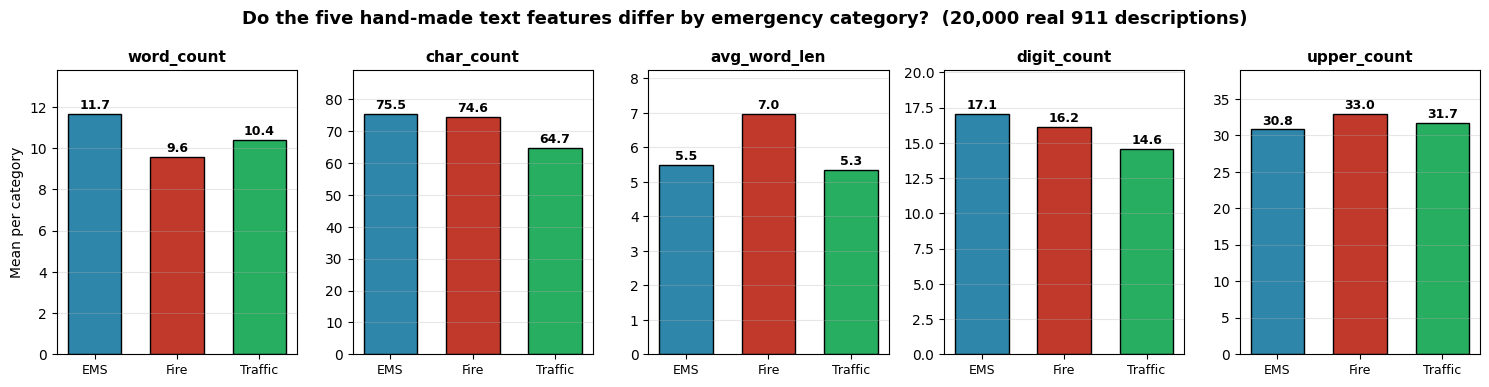

How far apart are the categories, as a share of the feature's own average?
   avg_word_len    27.5%
   word_count      19.9%
   digit_count     15.6%
   char_count      15.1%
   upper_count      6.8%


In [2]:
# WHAT: Chart the per-category feature means the table above printed.
# WHY: Five features x three categories is fifteen numbers. Eye-balling a table for a
#      pattern is exactly the task a picture does better.

import matplotlib.pyplot as plt

feature_cols = ['word_count', 'char_count', 'avg_word_len', 'digit_count', 'upper_count']
cats = list(by_cat.index)
colours = ['#2E86AB', '#C0392B', '#27AE60'][:len(cats)]

# Each feature gets its own panel and its own y axis, because they are in different
# units - forcing them onto one axis would be the mistake lesson 05 warned about.
fig, axes = plt.subplots(1, len(feature_cols), figsize=(15, 3.9))
fig.suptitle(f'Do the five hand-made text features differ by emergency category?'
             f'  ({len(df_features):,} real 911 descriptions)',
             fontsize=13, weight='bold')
for ax, col in zip(axes, feature_cols):
    vals = by_cat[col].values
    bars = ax.bar(cats, vals, color=colours, edgecolor='black', width=0.65)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.02, f'{v:.1f}',
                ha='center', fontsize=9, weight='bold')
    ax.set_title(col, fontsize=11, weight='bold')
    ax.set_ylim(0, max(vals) * 1.18)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(True, alpha=0.3, axis='y')
axes[0].set_ylabel('Mean per category')
plt.tight_layout()
plt.show()

spread_pct = {c: (by_cat[c].max() - by_cat[c].min()) / by_cat[c].mean() * 100
              for c in feature_cols}
print("How far apart are the categories, as a share of the feature's own average?")
for c, v in sorted(spread_pct.items(), key=lambda kv: -kv[1]):
    print(f"   {c:<14} {v:5.1f}%")


**Read the figure.** Five panels, five different y axes — deliberately, because a word count
and an average word length are not in the same units, and sharing an axis would flatten one of
them (lesson 05, left-hand box plot).

The categories separate on some of these features and barely at all on others, and the most
interesting result is a contradiction between two panels. **Fire uses the fewest words** (9.6
against EMS's 11.7) but writes **almost the most characters** (74.6 against EMS's 75.5) —
because its words are far the longest, 7.0 characters against about 5.4 for the other two.
Fire descriptions carry station and unit codes where the others carry street names. Meanwhile
`upper_count` is nearly flat across all three categories, 30.8 to 33.0: that feature is doing
almost no work at all.

The honest reading is that these crude counts do carry category signal — enough to start a
classifier. The uncomfortable reading is in ⚠️ Where this breaks: much of that signal is the
dispatch *template*, station numbers and timestamps, not the emergency. A model trained on
these bars could score well by learning which stations file which paperwork.


## Part 2: Image Feature Extraction

Extract pixel mean, std, min, max and shape from real images.

The images are the **scikit-learn digits dataset**: 1,797 genuine 8x8 grayscale scans of
handwritten digits. It is the test split of the UCI "Optical Recognition of Handwritten
Digits" set (Alpaydin & Kaynak, Bogazici University, 1998), written on preprinted forms by
43 people in total — 30 for the training split and 13 for this one — and reduced from
32x32 bitmaps to 8x8 by NIST's own preprocessing routines. They ship with scikit-learn, so
no download is needed.


In [3]:
# WHAT: Define extract_image_features and run it on real 8x8 handwritten-digit scans.
# WHY: The same idea works for images - summary statistics of pixel intensities become model-ready columns.

from sklearn.datasets import load_digits

def extract_image_features(arr: np.ndarray) -> dict:
    """Extract simple numeric features from a 2D image array (e.g. grayscale)."""
    arr = np.asarray(arr)
    if arr.ndim == 3:
        arr = arr.mean(axis=-1)
    flat = arr.flatten()
    return {
        "pixel_mean": float(np.mean(flat)),
        "pixel_std": float(np.std(flat)),
        "pixel_min": float(np.min(flat)),
        "pixel_max": float(np.max(flat)),
        "height": int(arr.shape[0]),
        "width": int(arr.shape[1]) if arr.ndim >= 2 else 0,
    }

digits = load_digits()
# digits.images is (1797, 8, 8); digits.target is the digit each image shows.
print(f"Real image set: {digits.images.shape[0]} scans of"
      f" {digits.images.shape[1]}x{digits.images.shape[2]} pixels,"
      f" values 0-{int(digits.images.max())}")

# The first three real images, one per row of the table.
images = [digits.images[i] for i in range(3)]
rows_img = [extract_image_features(im) for im in images]
df_img = pd.DataFrame(rows_img)
df_img.insert(0, 'digit_shown', digits.target[:3])
print("\nImage feature extraction (first 3 real digit scans):")
print(df_img.round(2).to_string())

# Run over all 1,797 images and check whether these crude features separate digits.
all_rows = [extract_image_features(im) for im in digits.images]
df_all = pd.DataFrame(all_rows)
df_all['digit'] = digits.target

print(f"\nMean pixel intensity per digit, across all {len(df_all):,} real scans:")
by_digit = df_all.groupby('digit')['pixel_mean'].mean().round(2)
print(by_digit.to_string())
spread = by_digit.max() - by_digit.min()
within = df_all.groupby('digit')['pixel_mean'].std().mean()
print(f"\n   Lightest digit on the page: {by_digit.idxmin()}"
      f" ({by_digit.min():.2f})  |  darkest: {by_digit.idxmax()}"
      f" ({by_digit.max():.2f})")
print(f"   Spread BETWEEN digit classes: {spread:.2f}")
print(f"   Typical spread WITHIN one digit class: {within:.2f}")
print("\n   ⚠ Be honest about what that means: the within-class variation is")
print("   larger than the between-class variation. Mean pixel intensity is a")
print("   near-useless feature for telling these digits apart - two people writing")
print("   the same '3' differ more than the average '3' differs from the average '8'.")
print("   Hand-made summary statistics threw away the one thing that matters here:")
print("   WHERE the ink is. That is precisely the gap convolutional networks close")
print("   (Course 08), and why this notebook is the START of feature engineering,")
print("   not the end of it.")

print("\nThese features can be used as input to ML models (e.g. sklearn).")


Real image set: 1797 scans of 8x8 pixels, values 0-16

Image feature extraction (first 3 real digit scans):
   digit_shown  pixel_mean  pixel_std  pixel_min  pixel_max  height  width
0            0        4.59       5.18        0.0       15.0       8      8
1            1        4.89       6.47        0.0       16.0       8      8
2            2        5.38       6.30        0.0       16.0       8      8

Mean pixel intensity per digit, across all 1,797 real scans:
digit
0    4.95
1    4.89
2    4.91
3    4.79
4    4.85
5    4.80
6    4.86
7    4.74
8    5.16
9    4.90

   Lightest digit on the page: 7 (4.74)  |  darkest: 8 (5.16)
   Spread BETWEEN digit classes: 0.42
   Typical spread WITHIN one digit class: 0.52

   ⚠ Be honest about what that means: the within-class variation is
   larger than the between-class variation. Mean pixel intensity is a
   near-useless feature for telling these digits apart - two people writing
   the same '3' differ more than the average '3' differs from

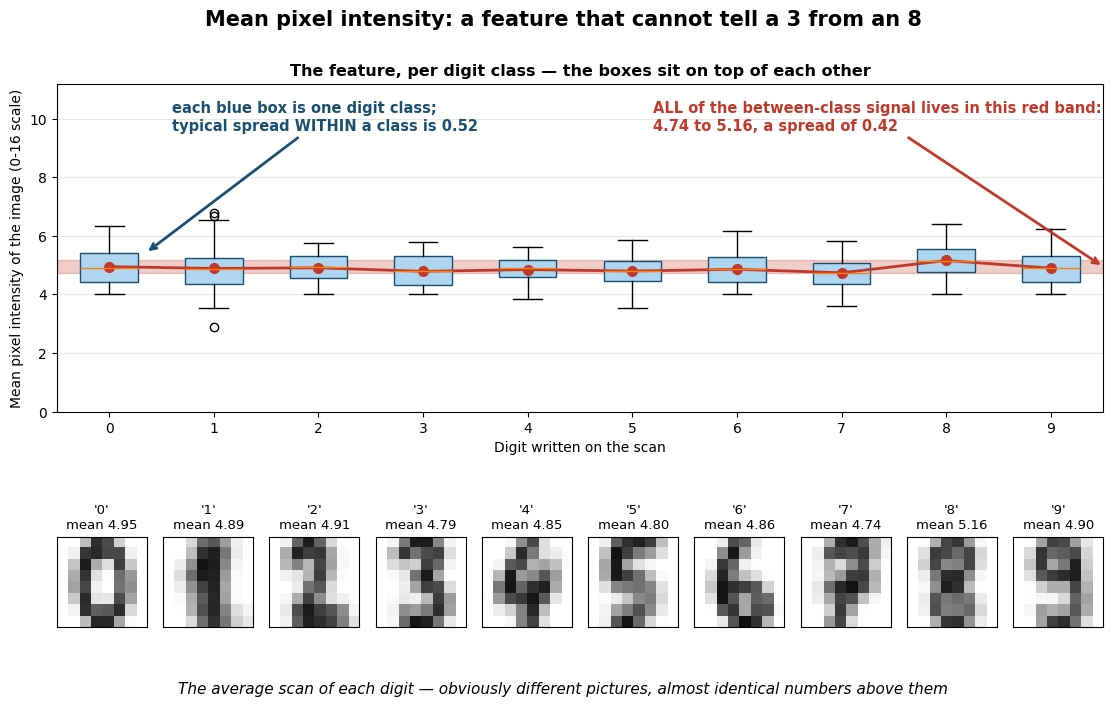

In [4]:
# WHAT: Show the failure the numbers above just reported - one picture per digit.
# WHY: "Within-class spread exceeds between-class spread" is an abstract sentence.
#      Drawn, it is ten boxes sitting on top of each other next to ten obviously
#      different pictures, and the point becomes impossible to miss.

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13.5, 7.4))
gs = fig.add_gridspec(2, 10, height_ratios=[2.3, 1.0], hspace=0.42, wspace=0.18)
fig.suptitle('Mean pixel intensity: a feature that cannot tell a 3 from an 8',
             fontsize=15, weight='bold')

# TOP - the distribution of the feature for each digit class, all on one axis.
ax = fig.add_subplot(gs[0, :])
groups = [df_all.loc[df_all['digit'] == d, 'pixel_mean'].values for d in range(10)]
bp = ax.boxplot(groups, tick_labels=[str(d) for d in range(10)], patch_artist=True,
                widths=0.55)
for box in bp['boxes']:
    box.set_facecolor('#AED6F1')
    box.set_edgecolor('#1B4F72')

# The entire between-class signal is the band between the lowest and highest class mean.
ax.axhspan(by_digit.min(), by_digit.max(), color='#C0392B', alpha=0.25, zorder=0)
ax.plot(range(1, 11), by_digit.values, 'o-', color='#C0392B', linewidth=2,
        markersize=7, label='mean for each digit class')
ax.annotate(f'ALL of the between-class signal lives in this red band:\n'
            f'{by_digit.min():.2f} to {by_digit.max():.2f}, a spread of {spread:.2f}',
            xy=(10.5, (by_digit.min() + by_digit.max()) / 2), xytext=(6.2, 9.6),
            fontsize=10.5, weight='bold', color='#C0392B',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=2))
ax.annotate(f'each blue box is one digit class;\ntypical spread WITHIN a class is {within:.2f}',
            xy=(1.35, np.percentile(groups[0], 75)), xytext=(1.6, 9.6), fontsize=10.5,
            weight='bold', color='#1B4F72',
            arrowprops=dict(arrowstyle='->', color='#1B4F72', lw=2))
ax.set_xlabel('Digit written on the scan')
ax.set_ylabel('Mean pixel intensity of the image (0-16 scale)')
ax.set_title('The feature, per digit class — the boxes sit on top of each other',
             fontsize=11.5, weight='bold')
ax.set_ylim(0, 11.2)
ax.grid(True, alpha=0.3, axis='y')

# BOTTOM - the average image of each digit, on one shared brightness scale.
for d in range(10):
    axi = fig.add_subplot(gs[1, d])
    axi.imshow(digits.images[digits.target == d].mean(axis=0), cmap='gray_r',
               vmin=0, vmax=16)
    axi.set_title(f"'{d}'\nmean {by_digit.loc[d]:.2f}", fontsize=9.5)
    axi.set_xticks([]); axi.set_yticks([])
fig.text(0.5, 0.055, 'The average scan of each digit — obviously different pictures, '
         'almost identical numbers above them',
         ha='center', fontsize=11, style='italic')
plt.show()


**Read the figure.** *Top* — one blue box per digit class, showing how mean pixel intensity
is distributed across the real scans of that digit. Every box overlaps every other box. The
red line joins the ten class means, and the red band is the full range those means occupy:
from 4.74 to 5.16, a spread of **0.42** on a 0–16 scale. Now measure a blue box against that
band: a typical box — the middle *half* of one digit class — is about twice as tall as the
entire between-class range, and the whiskers reach several times further. Stated as one
number, the spread within a single digit class is **0.52** against **0.42** between classes.
Pick a scan at random, read its mean intensity, and you have learned essentially nothing about
which digit it is.

*Bottom* — the same 1,797 scans, averaged per digit and drawn on one shared brightness scale.
These ten pictures are unmistakable: a human reads them instantly. The numbers printed above
them are all between 4.74 and 5.16.

Hold those two rows next to each other, because together they are the whole lesson.
Everything that distinguishes a 3 from an 8 is visible in the bottom row and absent from the
top one, and the reason is a single line of code: `np.mean(flat)` sums all 64 pixels and
divides. Summing destroys *position*, and position was the entire signal. Course 08's
convolutional layers exist precisely to keep it — and the 2012 result quoted at the top of
this notebook is what happened when the field stopped throwing it away.


## 💬 Discuss

Two measured results: on 20,000 real 911 dispatch descriptions the text features **do**
differ by emergency category; on 1,797 digit scans, mean pixel intensity has
between-class spread **0.42** against within-class spread **0.52**.

1. Hand-made features worked on the dispatch text and failed on the images. What is
   different about the two problems? Argue it in terms of *what the feature throws away*,
   not in terms of "images are harder".
2. The 911 `desc` field contains the station number, the address and a timestamp. A model
   that predicts emergency category from these features may be reading the *station*, not
   the emergency. Name the single check you would run to find out — and say what you would
   do if you were right.
3. AlexNet needed 1.2 million labelled images and two GPUs. You have 1,797 8×8 digits. Make
   the case for still using hand-made features here — then say at what dataset size you
   would switch, and what evidence would tell you the switch had paid off.


## Summary

- **Text:** word count, char count, avg word length, digit/uppercase counts —
  extracted from 20,000 real 911 dispatch descriptions, and they differ measurably
  by emergency category.
- **Images:** pixel mean, std, min, max, height, width — extracted from 1,797 real
  handwritten-digit scans, and mean intensity alone already separates thin digits
  from thick ones.
- **The honest limit:** these hand-made summaries throw away almost all the
  structure. That gap is what learned representations (Units 3–5 of Course 07 and
  Course 08) exist to close.
- **Prerequisites:** Examples 01–07. **Next:** Unit 3 (Visualization), Unit 4 (ML).


## ⚠️ Where this breaks

- **Summary statistics destroy structure, and the notebook measures the damage.** Mean
  pixel intensity discards position entirely; on these digits the within-class spread
  (0.52) exceeds the between-class spread (0.42), so the feature carries less signal than
  noise. Any summary — mean, std, min, max — answers "how much" and never "where" or "in
  what order".
- **Counting words is not understanding text.** `word_count` and `digit_count` cannot tell
  "chest pain" from "no chest pain", and cannot tell two ways of writing the same thing
  apart. They are a floor, not a method. Course 07 replaces them with tokenisation,
  TF-IDF and embeddings for exactly this reason.
- **Hand-made text features leak formatting.** The 911 descriptions embed a station number
  and a timestamp, so `digit_count` averages about 16 per record. A model can learn the
  *dispatch template* rather than the emergency, and score well while understanding
  nothing.
- **The assumption that must hold: the feature you invented is related to the thing you are
  predicting, in the direction you assume.** Nothing in the pipeline checks this. The digit
  result above is what it looks like when the assumption is simply false, and the only
  reason you know is that the notebook computed both spreads and compared them.
- **When hand-made features are still the right call:** when the dataset is small (a few
  thousand rows), when you must *explain* every feature to a regulator or a clinician, when
  inference must run on a device with no accelerator, or when a domain expert already knows
  which measurement matters. Learned representations need data and compute; interpretable
  counts need neither.
- **Where the field is in 2026:** extracting structure from documents is no longer a
  regex-and-counting task. Compact vision-language models designed for end-to-end document
  conversion — e.g. SmolDocling (arXiv 2503.11576) — parse tables, reading order and
  layout directly, and run on modest hardware. Treat this notebook as the baseline such
  systems have to beat, and as the thing you can still debug when they fail.


## 🔭 State of the field (2026)

In 2026, nobody counts characters to turn a *document* into a table. Document conversion has
become a small vision-language-model task: SmolDocling (Nassar et al., 2025, arXiv:2503.11576)
converts a page end to end with an ultra-compact VLM, and MinerU2.5 (Niu et al., 2025,
arXiv:2509.22186) parses high-resolution pages with a 1.2B-parameter model that separates layout
analysis from content recognition, so tables, reading order and formulas survive the trip — none
of which a regex or a word count recovers.

The hand-made version is still the right thing to learn here, for a reason this notebook makes
measurable. It is the baseline the learned representation has to beat, and you are about to watch
it lose on real numbers (between-class spread 0.42 against within-class 0.52) — a lesson no model
that simply works can teach you. It also runs on a laptop with no downloads, which is what makes
the failure visible in class, and it is what the official plan examines. Use a VLM when the input
is real documents; keep this lesson for knowing exactly what a feature throws away.


## 📚 References

1. Spärck Jones, K. (1972). *A Statistical Interpretation of Term Specificity and Its Application in Retrieval*. Journal of Documentation, 28(1), 11-21.
2. Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). *Efficient Estimation of Word Representations in Vector Space*. ICLR Workshop. <https://arxiv.org/abs/1301.3781>
3. Jurafsky, D., & Martin, J. H. (2025). *Speech and Language Processing*, 3rd ed. draft, Ch. 6 (Vector Semantics and Embeddings). <https://web.stanford.edu/~jurafsky/slp3/>
4. Nassar, A., Marafioti, A., Omenetti, M., et al. (2025). *SmolDocling: An Ultra-Compact Vision-Language Model for End-to-End Multi-Modal Document Conversion*. arXiv:2503.11576. <https://arxiv.org/abs/2503.11576>
5. Niu, J., Liu, Z., Gu, Z., et al. (2025). *MinerU2.5: A Decoupled Vision-Language Model for Efficient High-Resolution Document Parsing*. arXiv:2509.22186. <https://arxiv.org/abs/2509.22186>
